# yy08 — Generalised Label Transfer Demo

UMAP-based label transfer from VISp patchseq (source, labeled) to Minnie65 EM neurons (target, unlabeled),
using the new `LabelTransfer` class for both excitatory (EXC) and inhibitory (INH) cell types.

In [1]:
import sys
import os

sys.path.insert(0, ".")

%load_ext autoreload
%autoreload 2

import pandas as pd
from label_transfer import LabelTransfer

In [2]:
DATA_ROOT = '/scratch/combined_datasets'

## EXC — Excitatory label transfer

Transfer MET-type labels from VISp excitatory patchseq cells to Minnie65 excitatory EM neurons.

Source features: (389, 53)
Unique source cells: 384, unique labels: 17
Source after label join: (384, 56)
Target features: (49714, 58)
Shared features:  48
Only in source:   4  → ['axon_exit_theta', 'axon_exit_distance', 'heirachy_category', 'level']
Only in target:   7  → ['basal_dendrite_depth_pc_1', 'basal_dendrite_depth_pc_5', 'basal_dendrite_depth_pc_0', 'basal_dendrite_depth_pc_2', 'basal_dendrite_depth_pc_3', 'soma_surface_area', 'basal_dendrite_depth_pc_4']
Source: 384 → 384 rows (dropped 0)
Target: 49714 → 49714 rows (dropped 0)
Scaled source (standard): (384, 48)
Scaled target (standard): (49714, 48)


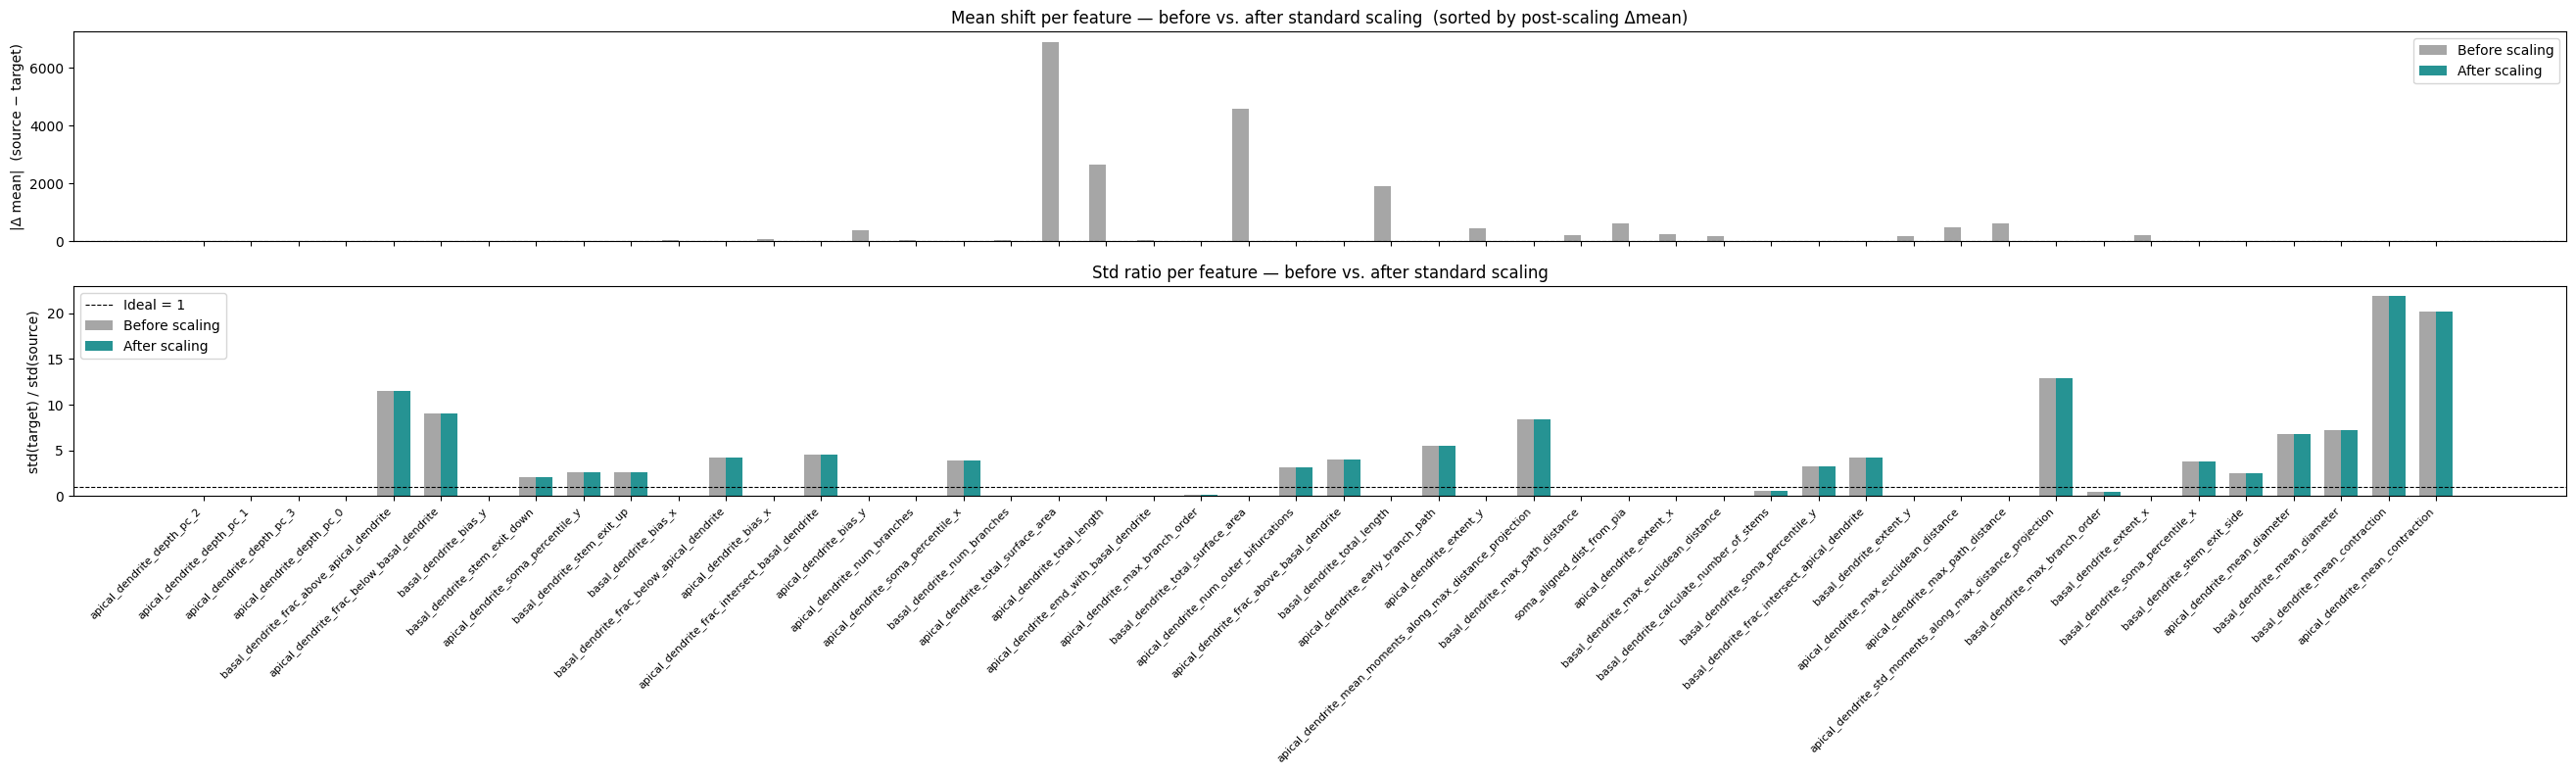

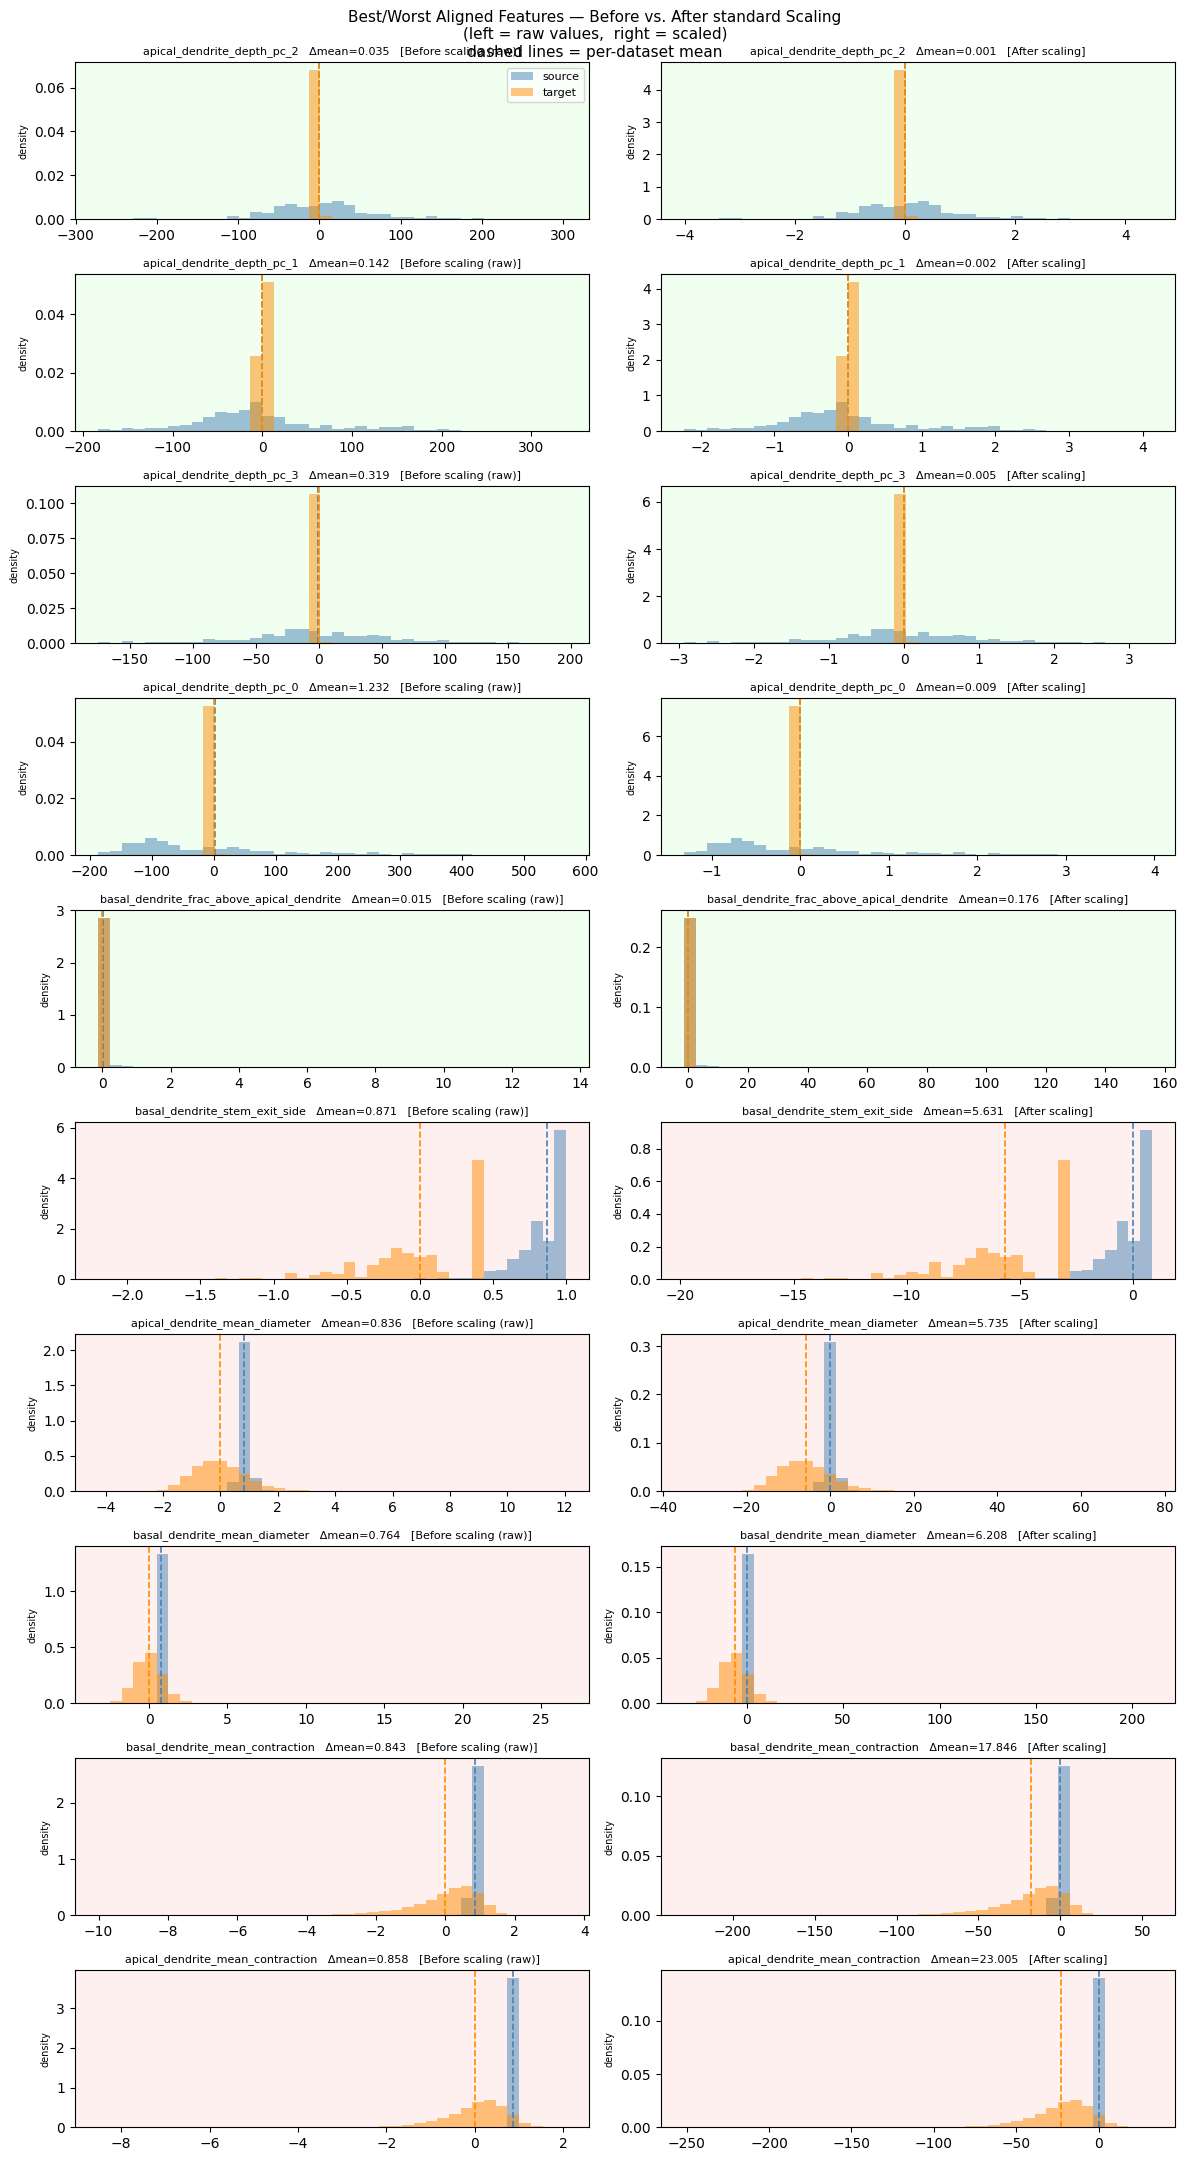

Source embedding (supervised): (384, 2)
Target embedding (supervised): (49714, 2)
Target predicted label counts:
  L4 IT                                              13551
  L5 IT-2                                            9146
  L5 IT-1                                            8463
  L6 IT-1                                            4860
  L5 IT-3 Pld5                                       3292
  L5/L6 IT Car3                                      2995
  L4/L5 IT                                           2360
  L5 NP                                              956
  L6b                                                903
  L6 CT-1                                            772
  L2/3 IT                                            687
  L6 IT-2                                            675
  L6 CT-2                                            363
  L6 IT-3                                            315
  L5 ET-3                                            211
  L5 ET-1 Chrna6        

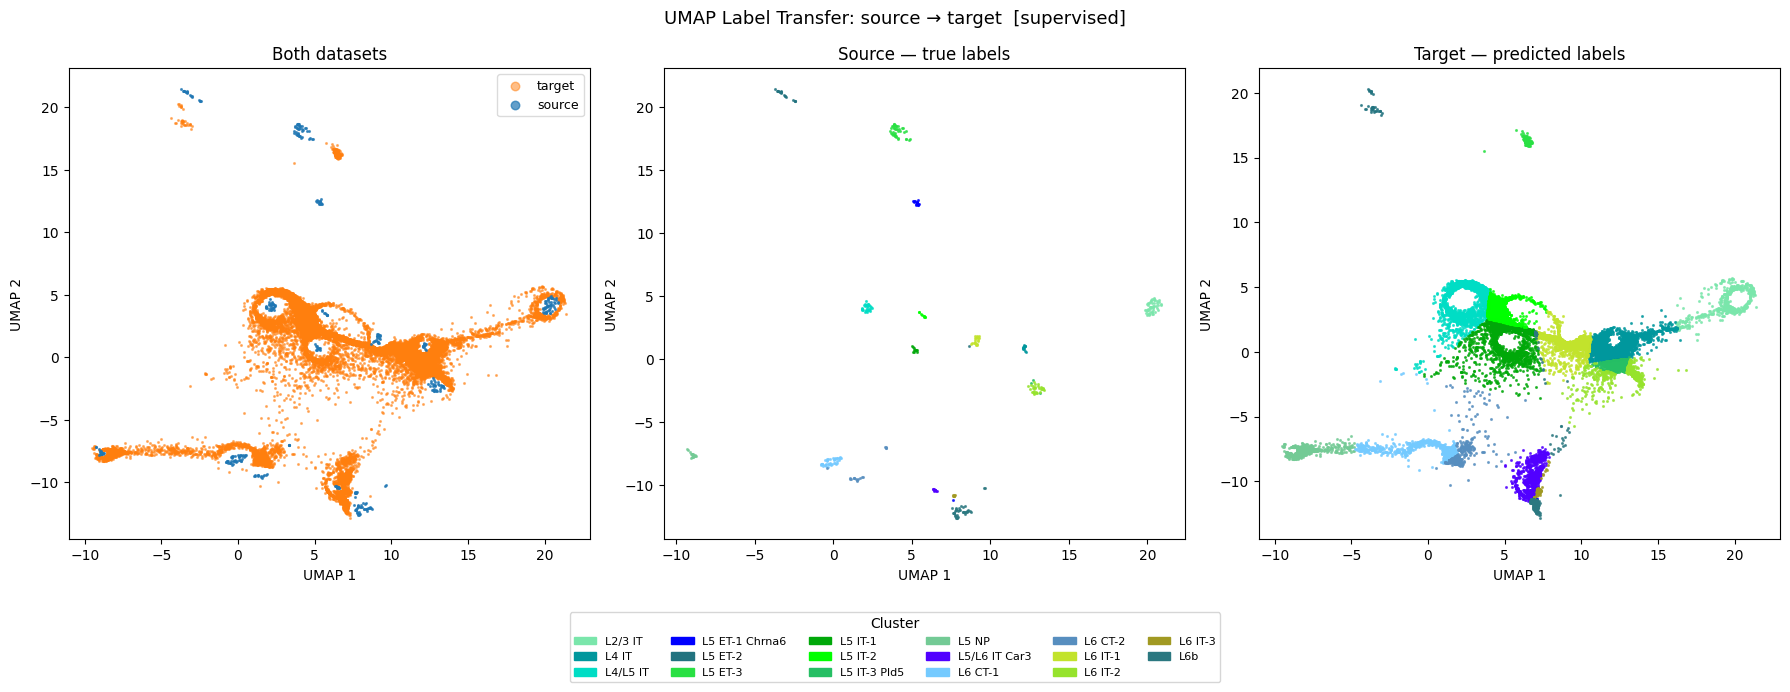

In [3]:
lt_exc = LabelTransfer(
    data_root=DATA_ROOT,
    source_features_subpath="cellfeatures/exc_morph_features",
    source_project_id="visp_exc_patchseq",
    source_feature_set_id="exc_visp_morph_features",
    target_features_subpath="cellfeatures/minnie_exc_skel_keys",
    target_project_id="minnie65",
    target_feature_set_id="minnie_exc_skel_keys",
    # source_label_taxonomy_project_id defaults to "visp_met_types"
)

exc_result = lt_exc.run(
    scaling_method="standard",
    umap_mode="supervised",
    plot_diagnostics=True,
)

In [4]:
exc_result.head()

,id,predicted_label
0,23141,L5 ET-1 Chrna6
1,23332,L4 IT
2,23373,L5 IT-1
3,23382,L4 IT
4,23385,L5 IT-1


## INH — Inhibitory label transfer

Transfer MET-type labels from VISp inhibitory patchseq cells to Minnie65 inhibitory EM neurons.

Source features: (520, 49)
Unique source cells: 495, unique labels: 28
Source after label join: (495, 52)
Target features: (163, 54)
Shared features:  46
Only in source:   2  → ['heirachy_category', 'level']
Only in target:   5  → ['basal_dendrite_depth_pc_1', 'basal_dendrite_depth_pc_0', 'basal_dendrite_depth_pc_2', 'basal_dendrite_depth_pc_3', 'basal_dendrite_depth_pc_4']
Source: 495 → 495 rows (dropped 0)
Target: 163 → 163 rows (dropped 0)
Scaled source (standard): (495, 46)
Scaled target (standard): (163, 46)


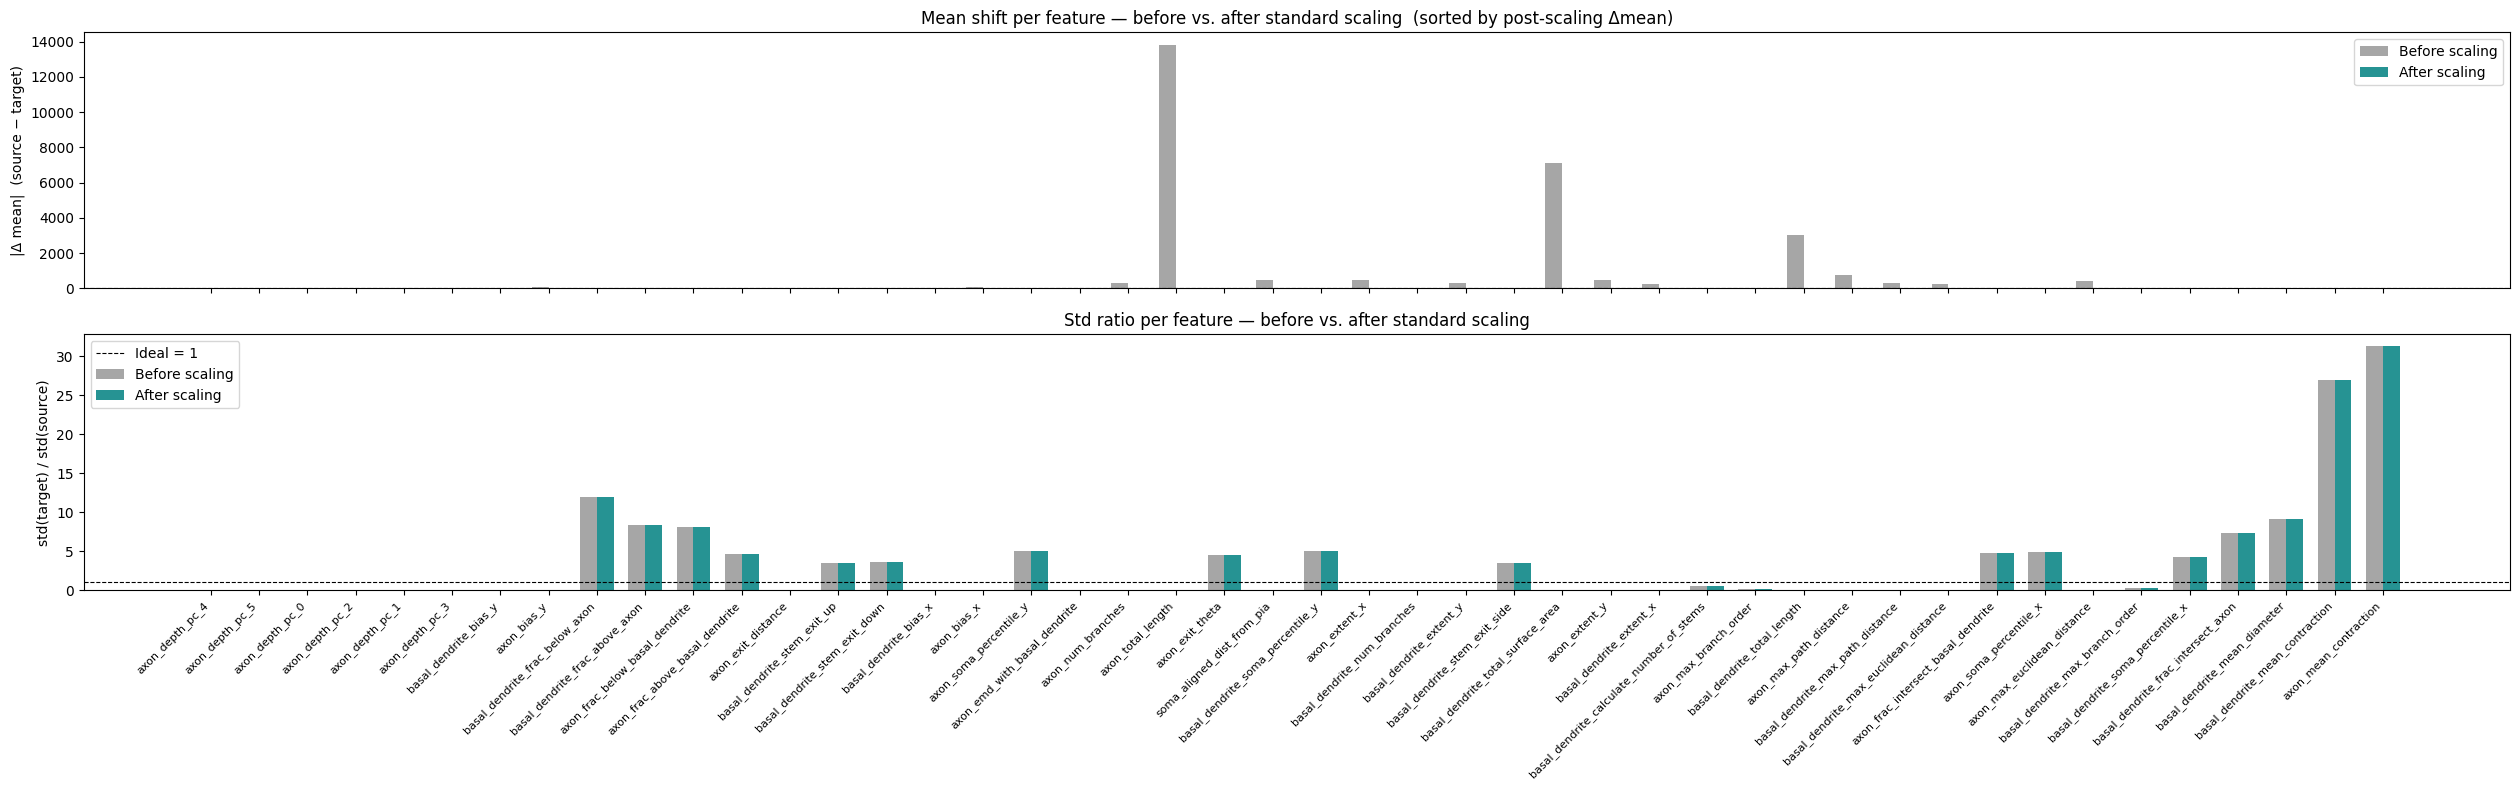

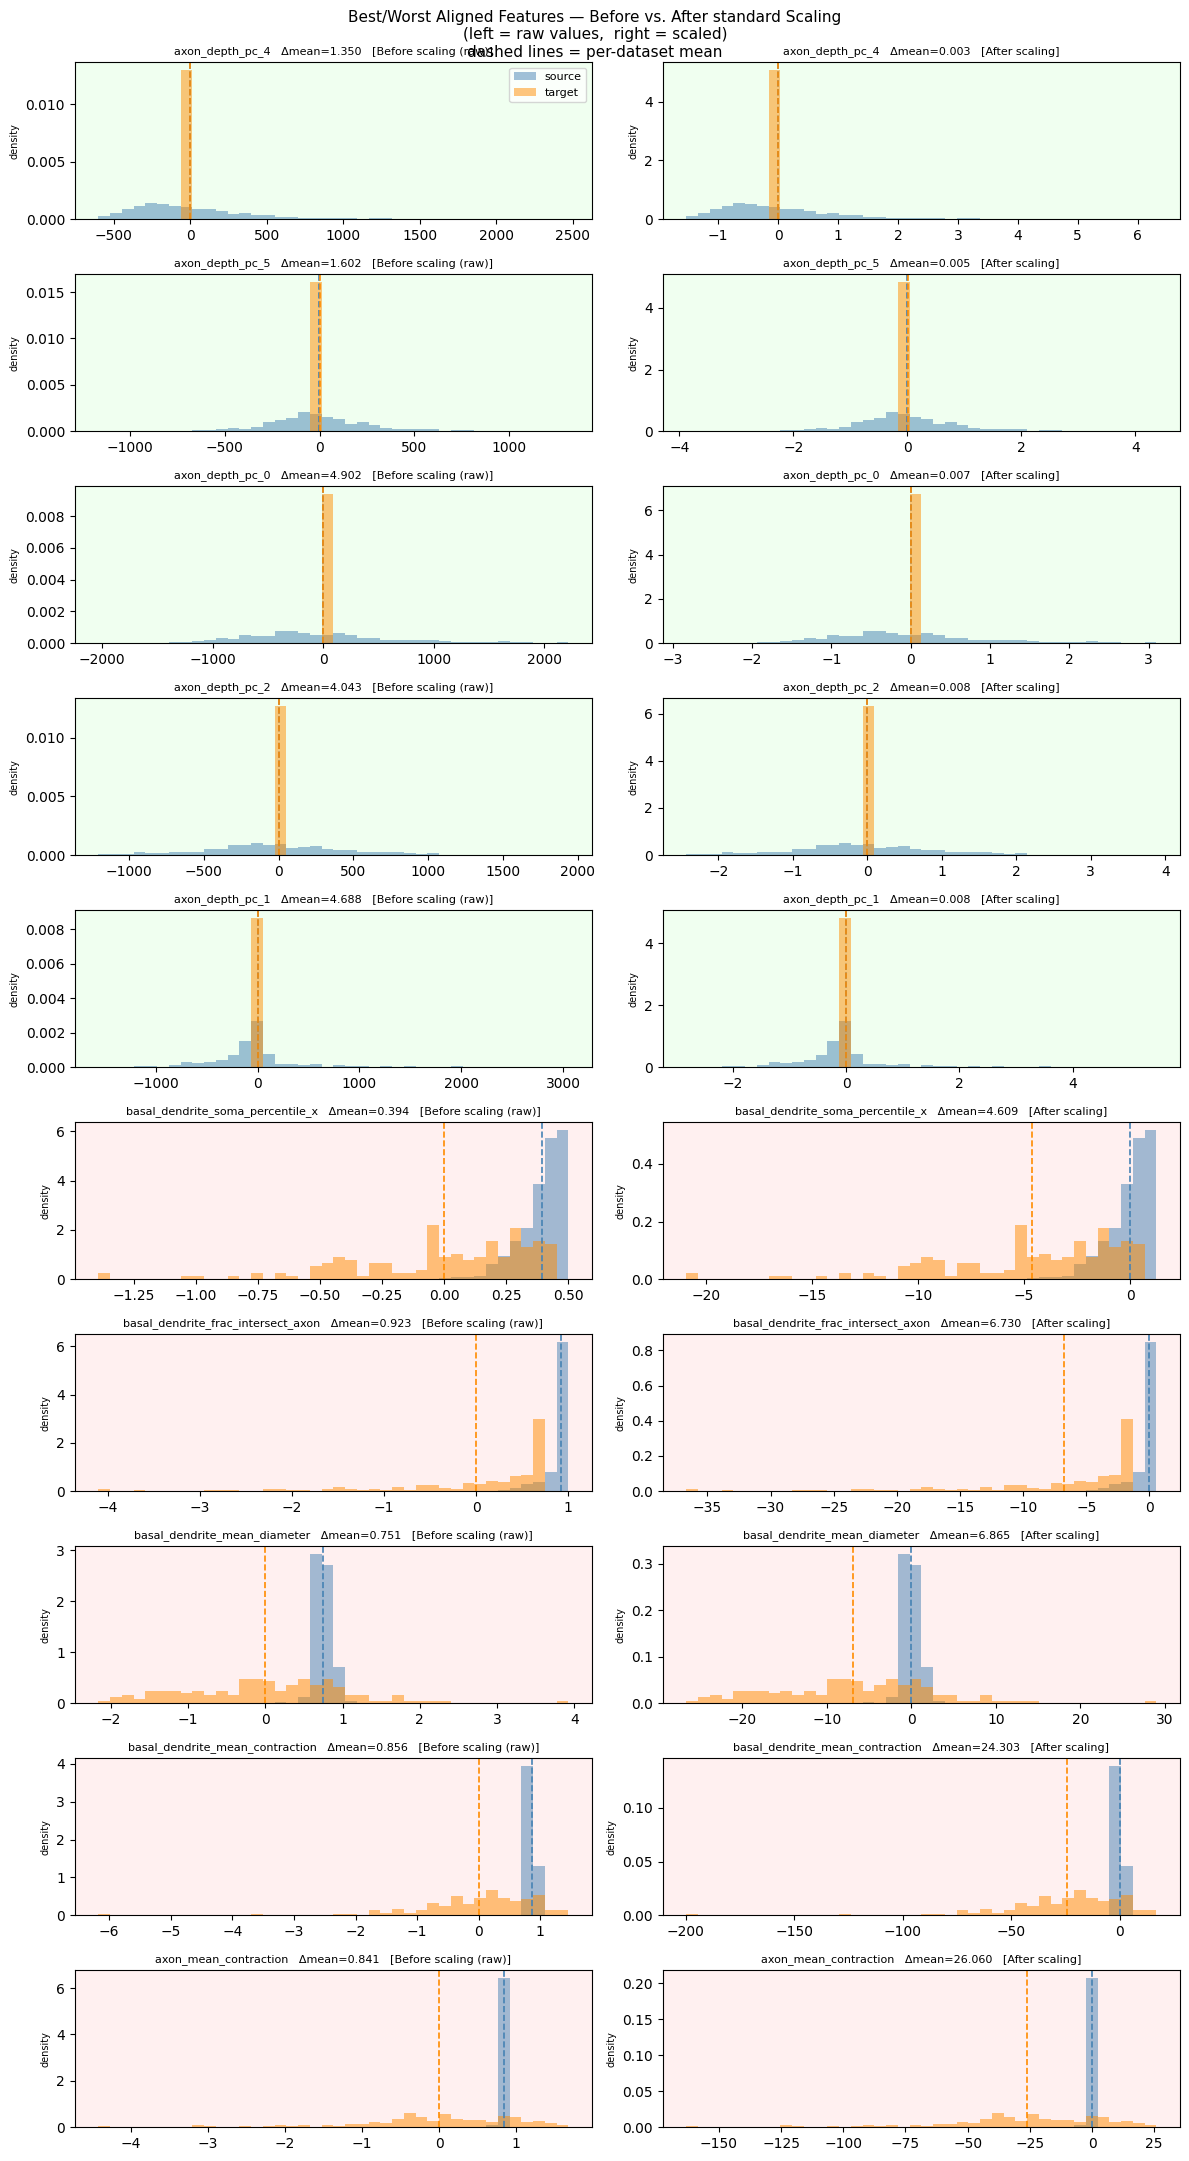

Source embedding (supervised): (495, 2)
Target embedding (supervised): (163, 2)
Target predicted label counts:
  Vip-MET-5                                          54
  Vip-MET-2                                          27
  Sst-MET-9                                          12
  Vip-MET-1                                          12
  Pvalb-MET-4                                        11
  Pvalb-MET-3                                        8
  Sst-MET-7                                          8
  Pvalb-MET-1                                        7
  Sst-MET-1                                          6
  Sst-MET-12                                         4
  Sst-MET-2                                          3
  Lamp5-MET-1                                        2
  Sst-MET-10                                         2
  Sst-MET-4                                          2
  Sst-MET-6                                          2
  Sncg-MET-1                                         1
  Ss

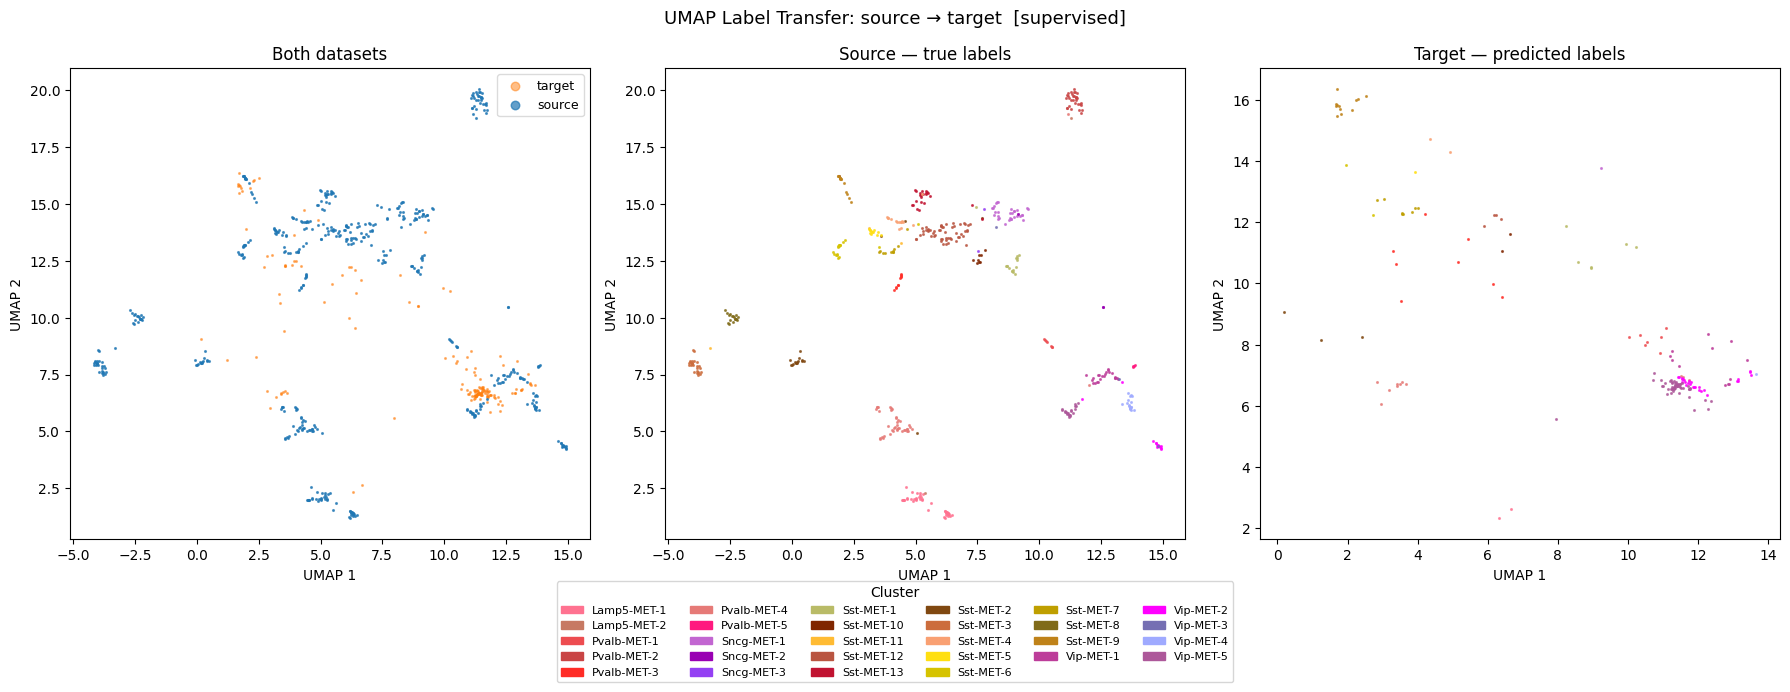

In [5]:
lt_inh = LabelTransfer(
    data_root=DATA_ROOT,
    source_features_subpath="cellfeatures/inh_morph_features",
    source_project_id="visp_inh_patchseq",
    source_feature_set_id="inh_visp_morph_features",
    target_features_subpath="cellfeatures/minnie_inh_skel_keys",
    target_project_id="minnie65",
    target_feature_set_id="minnie_inh_skel_keys",
    # source_label_taxonomy_project_id defaults to "visp_met_types"
)

inh_result = lt_inh.run(
    scaling_method="standard",
    umap_mode="supervised",
    plot_diagnostics=True,
)

In [6]:
inh_result.head()

,id,predicted_label
0,252232,Vip-MET-5
1,255120,Vip-MET-5
2,255129,Vip-MET-2
3,255137,Vip-MET-5
4,255208,Vip-MET-5


## Combined results

In [7]:
all_results = pd.concat([exc_result, inh_result], ignore_index=True)
print(f"Total cells: {len(all_results)}")
all_results["predicted_label"].value_counts()

Total cells: 49877


predicted_label
L4 IT             13551
L5 IT-2            9146
L5 IT-1            8463
L6 IT-1            4860
L5 IT-3 Pld5       3292
L5/L6 IT Car3      2995
L4/L5 IT           2360
L5 NP               956
L6b                 903
L6 CT-1             772
L2/3 IT             687
L6 IT-2             675
L6 CT-2             363
L6 IT-3             315
L5 ET-3             211
L5 ET-1 Chrna6      131
Vip-MET-5            54
L5 ET-2              34
Vip-MET-2            27
Vip-MET-1            12
Sst-MET-9            12
Pvalb-MET-4          11
Pvalb-MET-3           8
Sst-MET-7             8
Pvalb-MET-1           7
Sst-MET-1             6
Sst-MET-12            4
Sst-MET-2             3
Lamp5-MET-1           2
Sst-MET-10            2
Sst-MET-4             2
Sst-MET-6             2
Vip-MET-4             1
Sst-MET-5             1
Sncg-MET-1            1
Name: count, dtype: int64

In [8]:
all_results

,id,predicted_label
0,23141,L5 ET-1 Chrna6
1,23332,L4 IT
2,23373,L5 IT-1
3,23382,L4 IT
4,23385,L5 IT-1
...,...,...
49872,309481,Sst-MET-12
49873,309508,Vip-MET-5
49874,309578,Vip-MET-1
49875,342232,Sncg-MET-1
